# Notebook 1 EDA: Exploratory Data Analysis .single-cell RNA-seq
**Project 2: Classification of Cell Types**

In [26]:
# Trova la radice del progetto 
import sys, pathlib

def _find_root(start=None):
    p = (start or pathlib.Path.cwd()).resolve()
    for _ in range(6):
        if (p / "src" / "setup.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Radice del progetto non trovata (manca src/setup.py).\n"
        "Apri il notebook dalla cartella del repo o da notebooks/."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification


In [ ]:
# Import e caricamento 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.data_loader import load_datasets
from src.setup import FIGURES_DIR

from src.gene_groups import GENE_SUBGROUPS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train, X_test, y_train, y_test = load_datasets()

print("File di training:")
print(f"  data_train/X_train.csv → {X_train.shape[0]} celle × {X_train.shape[1]} geni")
print(f"  data_train/y_train.csv → {len(y_train)} etichette")
print("(X_test e y_test caricati in memoria per le sezioni successive, non mostrati qui.)")


File di training:
  data_train/X_train.csv → 4516 celle × 1976 geni
  data_train/y_train.csv → 4516 etichette
(X_test e y_test caricati in memoria per le sezioni successive, non mostrati qui.)


## 1. Description dataset (train)

Ogni **riga** di `X_train.csv` è una cellula, ogni **colonna** un gene.
`y_train.csv` contiene il **tipo cellulare** (`predicted_labels`).



In [ ]:

print("data_train/X_train.csv")
print(f"  Shape   : {X_train.shape[0]} celle × {X_train.shape[1]} geni")
print(f"  Dtype   : {dict(X_dtypes := X_train.dtypes.value_counts())}")
print(f"  Memoria : {X_train.memory_usage().sum() / 1e6:.1f} MB")
print(f"  Nulli   : {int(X_train.isna().sum().sum())}")
print()

n_genes = X_train.shape[1]
gene_names = X_train.columns.tolist()
print(f"Feature (geni HVG): {n_genes}")
if n_genes <= 20:
    print("Nomi:", ", ".join(gene_names))
else:
    print("Nomi (primi 10):", ", ".join(gene_names[:10]))
    print("             ...")
    print("Nomi (ultimi 5) :", ", ".join(gene_names[-5:]))

print()
print("Valori mancanti e geni inattivi:")
print(f"  NA nel train: {int(X_train.isna().sum().sum())}")
print("  Dati z-score: media globale ≈ 0, σ ≈ 1 per gene.")
gene_min = X_train.min()
n_at_floor = int((X_train == gene_min).sum().sum())
print(f"  Valore minimo nel train: {gene_min.min():.3f} (varia per gene)")
print(f"  Celle al minimo di almeno un gene: {n_at_floor:,} — tipico di geni poco espressi, non NA.")
print("  Gene poco attivo ≈ valori negativi o vicini al minimo del gene (non è NA).")

print()
n_cells = len(y_train)
class_counts = y_train.value_counts().reset_index()
class_counts.columns = ["cell_type", "n_celle"]
class_counts["pct"] = (class_counts["n_celle"] / n_cells * 100).round(1)
total_row = pd.DataFrame([{"cell_type": "Total", "n_celle": n_cells, "pct": 100.0}])
class_table = pd.concat([class_counts, total_row], ignore_index=True)
print(f"Classi in y_train: {y_train.nunique()} tipi cellulari")
class_table




data_train/X_train.csv
  Shape   : 4516 celle × 1976 geni
  Dtype   : {dtype('float64'): np.int64(1976)}
  Memoria : 71.4 MB
  Nulli   : 0

Feature (geni HVG): 1976
Nomi (primi 10): HES4, ISG15, TNFRSF18, TNFRSF4, B3GALT6, ACAP3, PLCH2, SMIM1, ACOT7, TNFRSF25
             ...
Nomi (ultimi 5) : ICOSLG, ADARB1, COL6A2, DIP2A, S100B

Valori mancanti e geni inattivi:
  NA nel train: 0
  Dati z-score: media globale ≈ 0, σ ≈ 1 per gene.
  Valore minimo nel train: -2.352 (varia per gene)
  Celle al minimo di almeno un gene: 7,833,985 — tipico di geni poco espressi, non NA.
  Gene poco attivo ≈ valori negativi o vicini al minimo del gene (non è NA).

Classi in y_train: 19 tipi cellulari


,cell_type,n_celle,pct
0,CD14 Monocyte,1511,33.500
1,CD8m T,814,18.000
2,NK,710,15.700
3,B,646,14.300
4,CD4n T,219,4.800
5,Platelet,137,3.000
6,CD16 Monocyte,133,2.900
7,gd T,127,2.800
8,CD4m T,108,2.400
9,DC,31,0.700



## 2. Distribuzione delle classi 



In [29]:
counts = pd.DataFrame({
    "train": y_train.value_counts(),
}).fillna(0).astype(int).sort_values("train", ascending=False)

n_train = int(y_train.shape[0])
counts["pct"] = (counts["train"] / n_train * 100).round(1)

# Rapporto classe più frequente / più rara
ratio_imb = counts["train"].max() / counts["train"].min()
max_cls = counts["train"].idxmax()
min_cls = counts["train"].idxmin()
print(f"Numero totale di classi: {len(counts)}")
print(
    f"Classe più frequente (train): '{max_cls}' → "
    f"{counts.loc[max_cls, 'train']} celle ({counts.loc[max_cls, 'pct']:.1f}%)"
)
print(
    f"Classe più rara    (train): '{min_cls}' → "
    f"{counts.loc[min_cls, 'train']} celle ({counts.loc[min_cls, 'pct']:.1f}%)"
)
print(f"Rapporto di sbilanciamento: {ratio_imb:.0f}:1\n")
print(counts.to_string())

Numero totale di classi: 19
Classe più frequente (train): 'CD14 Monocyte' → 1511 celle (33.5%)
Classe più rara    (train): 'Neutrophil' → 2 celle (0.0%)
Rapporto di sbilanciamento: 756:1

                  train    pct
cell_type                     
CD14 Monocyte      1511 33.500
CD8m T              814 18.000
NK                  710 15.700
B                   646 14.300
CD4n T              219  4.800
Platelet            137  3.000
CD16 Monocyte       133  2.900
gd T                127  2.800
CD4m T              108  2.400
DC                   31  0.700
CD8eff T             22  0.500
CD4 T                20  0.400
IgA PB               15  0.300
pDC                   7  0.200
IgG PB                4  0.100
RBC                   4  0.100
Class-switched B      3  0.100
SC & Eosinophil       3  0.100
Neutrophil            2  0.000


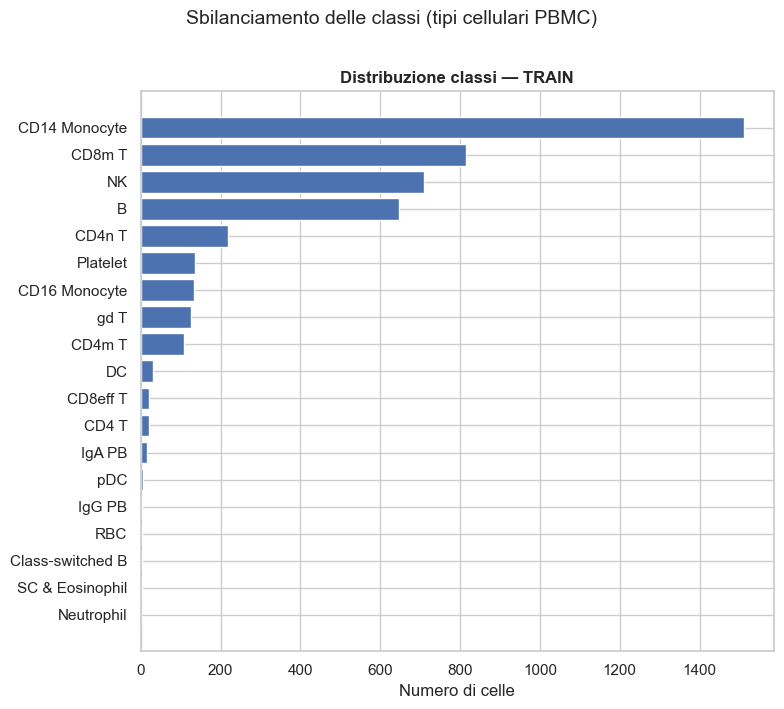

Figura salvata.


In [30]:
order = counts.index[::-1]
fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(order, counts.loc[order, "train"], color="#4c72b0")
ax.set_title("Distribuzione classi — TRAIN", fontweight="bold")
ax.set_xlabel("Numero di celle")

plt.suptitle("Sbilanciamento delle classi (tipi cellulari PBMC)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")


## 3. Analisi dei geni discriminanti: criterio 1σ




In [ ]:
# Medie per classe 
df_tr = X_train.copy()
df_tr["cell_type"] = y_train.values
class_means = df_tr.groupby("cell_type").mean()

print(f"class_means: {class_means.shape[0]} classi × {class_means.shape[1]} geni")

# Preview: 5 classi più frequenti × marcatori da GENE_SUBGROUPS
top5_classes = y_train.value_counts().head(5).index.tolist()
preview_genes = []
for genes in GENE_SUBGROUPS.values():
    preview_genes.extend([g for g in genes if g in X_train.columns])
preview_genes = list(dict.fromkeys(preview_genes))[:8]
print("\nAnteprima (5 classi più frequenti × 8 marcatori):")
display(class_means.loc[top5_classes, preview_genes].round(3))


class_means: 19 classi × 1976 geni

Anteprima (5 classi più frequenti × 8 marcatori):


,CD3E,CD3D,CD3G,IL7R,TRAC,CD8A,CD8B,MS4A1
cell_type,,,,,,,,
CD14 Monocyte,-0.688,-0.558,-0.513,-0.463,-0.497,-0.381,-0.316,-0.370
CD8m T,1.176,1.312,1.240,0.778,1.186,1.272,1.229,-0.348
NK,0.391,-0.155,-0.143,-0.372,-0.347,-0.096,-0.302,-0.366
B,-0.721,-0.611,-0.573,-0.470,-0.481,-0.382,-0.321,2.185
CD4n T,0.895,0.695,0.685,1.569,0.950,-0.184,-0.009,-0.386


In [32]:
global_std  = X_train.std()

# Escursione tra classi per ogni gene
spread = class_means.max(axis=0) - class_means.min(axis=0)
ratio  = (spread / global_std).sort_values(ascending=False)

discriminanti = ratio[ratio > 1]
n_signif = len(discriminanti)
print(f"Geni con escursione > 1σ (discriminanti): {n_signif} su {X_train.shape[1]}")
print(f"({n_signif/X_train.shape[1]*100:.1f}% dei geni totali)\n")

# Top 20 tra i soli geni con rapporto_sigma > 1
top20 = discriminanti.head(20)
tabella = pd.DataFrame({
    "classe_max"    : class_means[top20.index].idxmax(),
    "media_max"     : class_means[top20.index].max().round(3),
    "classe_min"    : class_means[top20.index].idxmin(),
    "media_min"     : class_means[top20.index].min().round(3),
    "escursione"    : spread[top20.index].round(3),
    "sigma_globale" : global_std[top20.index].round(3),
    "rapporto_sigma": top20.round(3),
})
print("Top 20 geni più discriminanti (tutti con rapporto_sigma > 1):")
tabella


Geni con escursione > 1σ (discriminanti): 1199 su 1976
(60.7% dei geni totali)

Top 20 geni più discriminanti (tutti con rapporto_sigma > 1):


,classe_max,media_max,classe_min,media_min,escursione,sigma_globale,rapporto_sigma
IGHG1,IgG PB,13.272,Class-switched B,-0.186,13.458,0.986,13.651
IGHG4,IgG PB,11.727,CD4 T,-0.194,11.922,0.998,11.951
SERPINF1,pDC,11.666,CD4 T,-0.104,11.770,0.987,11.922
IGHG3,IgG PB,9.902,Class-switched B,-0.228,10.130,0.996,10.173
LINC02018,Class-switched B,9.061,CD4 T,-0.067,9.128,0.954,9.569
HEMGN,Class-switched B,9.022,B,-0.063,9.086,0.985,9.224
MYBL2,IgG PB,8.884,CD16 Monocyte,-0.109,8.993,0.976,9.215
GPR107,Neutrophil,8.754,CD4 T,-0.264,9.018,1.008,8.947
ZNF41,Class-switched B,8.513,CD4 T,-0.113,8.626,0.964,8.945
IGKV4-1,IgG PB,9.253,NK,-0.058,9.311,1.048,8.882


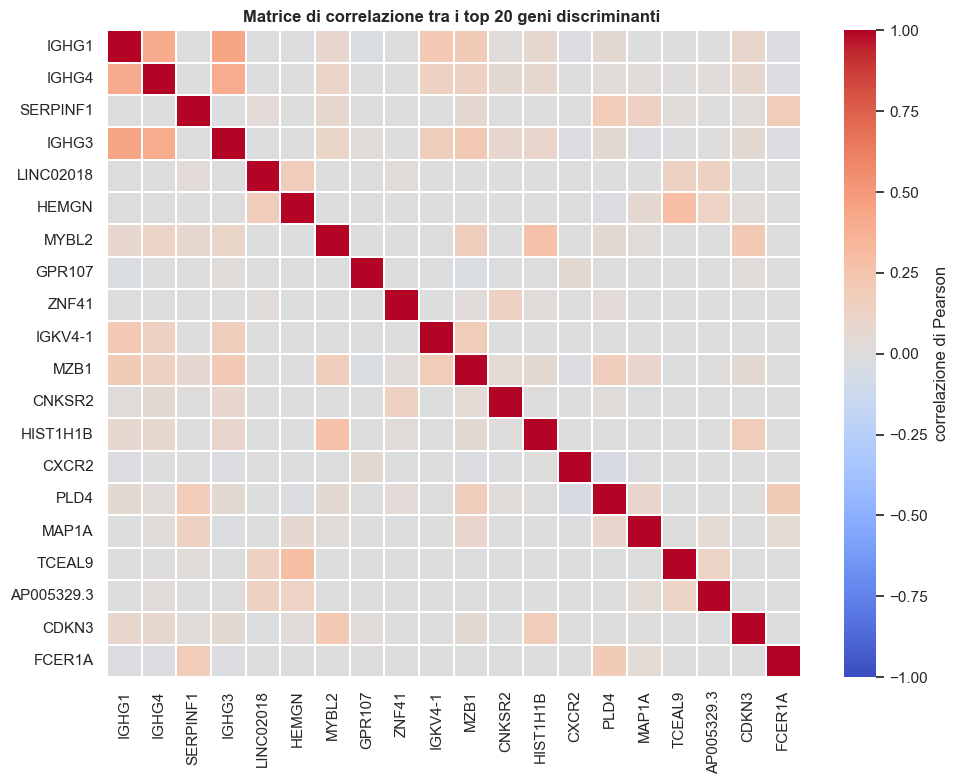

Figura salvata.


In [33]:
# Correlazione tra top 20 discriminanti

corr_top20 = X_train[top20.index].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_top20, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.2, cbar_kws={"label": "correlazione di Pearson"},
)
ax.set_title("Matrice di correlazione tra i top 20 geni discriminanti ",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_corr_top20_discriminanti.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")


## 4. Heatmap z-score delle medie per classe


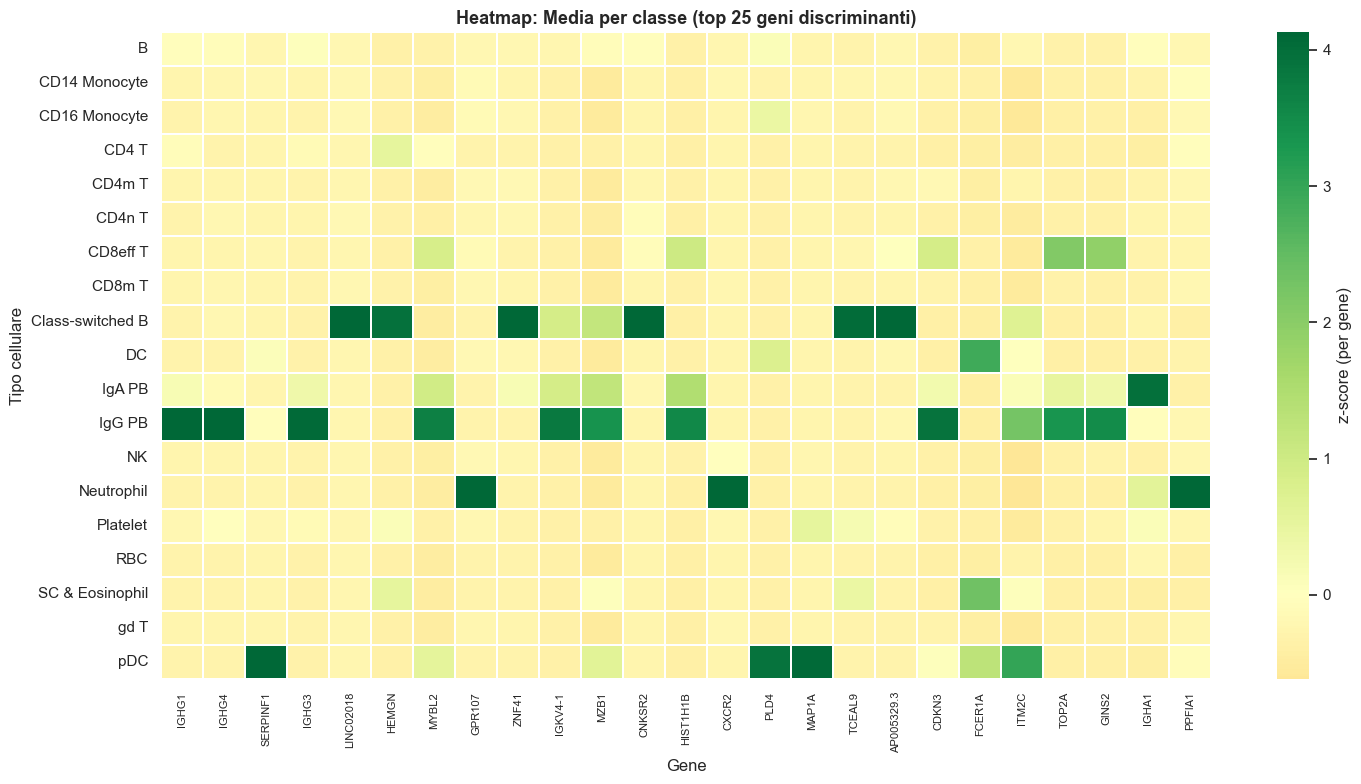

Figura salvata.


In [34]:
top_genes_hm = ratio.head(25).index
means_sub    = class_means[top_genes_hm]
means_norm   = (means_sub - means_sub.mean()) / (means_sub.std() + 1e-9)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    means_norm, annot=False, cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.3, cbar_kws={"label": "z-score (per gene)"}
)
ax.set_title("Heatmap: Media per classe (top 25 geni discriminanti)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Gene"); ax.set_ylabel("Tipo cellulare")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_heatmap_zscore.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

## 5. Gruppi di geni funzionali: feature engineering


In [ ]:
# composizione di gruppi di geni funzionali 

print("Gruppi biologici definiti in GENE_SUBGROUPS:\n")

rows_comp = []
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in X_train.columns]
    assenti  = [g for g in geni  if g not in X_train.columns]
    rows_comp.append({
        "gruppo"          : gruppo,
        "geni_totali"     : len(geni),
        "presenti_HVG"    : ", ".join(presenti) if presenti else "—",
        "assenti_HVG"     : ", ".join(assenti)  if assenti  else "—",
    })

comp_df = pd.DataFrame(rows_comp)
print(comp_df.to_string(index=False))
print("Presenza negli HVG e potere discriminante per gruppo biologico:\n")

rows = []
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in X_train.columns]
    if not presenti:
        rows.append({
            "gruppo"         : gruppo,
            "geni_HVG"       : f"0/{len(geni)}",
            "ratio_σ_medio"  : None,
            "gene_top"       : "—",
            "ratio_σ_max"    : None,
        })
        continue
    ratio_vals = ratio[presenti]
    rows.append({
        "gruppo"         : gruppo,
        "geni_HVG"       : f"{len(presenti)}/{len(geni)}",
        "ratio_σ_medio"  : round(ratio_vals.mean(), 3),
        "gene_top"       : ratio_vals.idxmax(),
        "ratio_σ_max"    : round(ratio_vals.max(), 3),
    })

summary_df = (
    pd.DataFrame(rows)
    .sort_values("ratio_σ_medio", ascending=False)
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))


Gruppi biologici definiti in GENE_SUBGROUPS:

        gruppo  geni_totali                              presenti_HVG         assenti_HVG
        T_cell            8  CD3E, CD3D, CD3G, IL7R, TRAC, CD8A, CD8B                 CD4
        B_cell            8 MS4A1, CD79A, CD79B, JCHAIN, IGHA1, IGHG1          CD19, CD74
       Myeloid            7                FCGR3A, CD14, CST3, TYROBP LYZ, S100A8, S100A9
            NK            5                         PRF1, GZMB, KLRD1          NKG7, GNLY
      Platelet            2                                 PPBP, PF4                   —
        DC_pDC            4                        FCER1A, CST3, GZMB               IL3RA
Interferon_ISG            4                  ISG15, MX1, IFIT1, IFIT3                   —
           MHC            4     HLA-DRA, HLA-DRB1, HLA-DPA1, HLA-DPB1                   —
Presenza negli HVG e potere discriminante per gruppo biologico:

        gruppo geni_HVG  ratio_σ_medio gene_top  ratio_σ_max
        B_cell    

In [47]:
# Calcolo degli score e salvataggio

DATA_DIR = ROOT / "data_train"   # stessa cartella di X_train.csv / y_train.csv

def compute_group_scores(X: pd.DataFrame, gene_groups: dict) -> pd.DataFrame:
    """Ritorna un DataFrame con una colonna score_<gruppo> per ogni gruppo
    che ha almeno un gene presente in X."""
    scores = {}
    for group, genes in gene_groups.items():
        present = [g for g in genes if g in X.columns]
        if present:
            scores[f"score_{group}"] = X[present].mean(axis=1)
    return pd.DataFrame(scores, index=X.index)

scores_train = compute_group_scores(X_train, GENE_SUBGROUPS)
scores_test  = compute_group_scores(X_test,  GENE_SUBGROUPS)

# Salvataggio
out_train = DATA_DIR / "scores_train.csv"
out_test  = DATA_DIR / "scores_test.csv"
scores_train.to_csv(out_train)
scores_test.to_csv(out_test)

print(f"Score calcolati: {scores_train.shape[1]} feature per gruppo")

print()
print(scores_train.describe().round(3))


Score calcolati: 8 feature per gruppo

       score_T_cell  score_B_cell  score_Myeloid  score_NK  score_Platelet  \
count      4516.000      4516.000       4516.000  4516.000        4516.000   
mean          0.002        -0.000         -0.004    -0.007          -0.003   
std           0.753         0.664          0.718     0.913           0.941   
min          -0.546        -0.335         -0.764    -0.595          -0.420   
25%          -0.546        -0.335         -0.764    -0.595          -0.420   
50%          -0.546        -0.335         -0.129    -0.595          -0.420   
75%           0.580        -0.042          0.692     0.518          -0.002   
max           2.680         5.017          1.776     3.091           6.518   

       score_DC_pDC  score_Interferon_ISG  score_MHC  
count      4516.000              4516.000   4516.000  
mean         -0.004                 0.006     -0.003  
std           0.522                 0.761      0.880  
min          -0.505                -0.

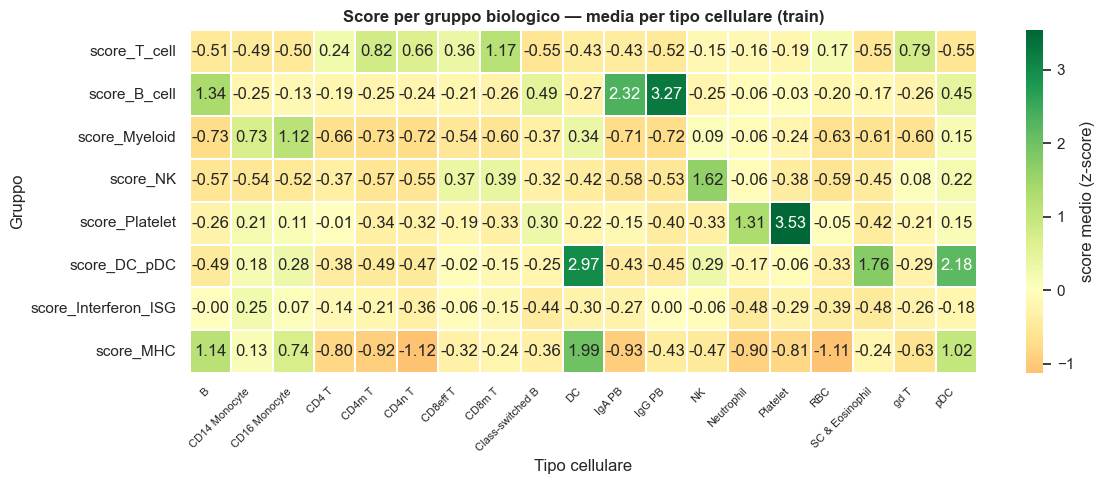

Figura salvata.


In [48]:
# Distribuzione degli score per tipo cellulare (heatmap)

score_means = scores_train.copy()
score_means["cell_type"] = y_train.values
heatmap_df = score_means.groupby("cell_type").mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_df.T,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    linewidths=0.3, ax=ax,
    cbar_kws={"label": "score medio (z-score)"},
)
ax.set_title("Score per gruppo biologico — media per tipo cellulare (train)",
             fontweight="bold")
ax.set_xlabel("Tipo cellulare")
ax.set_ylabel("Gruppo")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_group_scores_by_celltype.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")


## 6. Boxplot dei top geni per gruppo biologico



In [ ]:
# gene rappresentativo per ogni gruppo biologico
rep_genes = {}
for gruppo, geni in GENE_SUBGROUPS.items():
    presenti = [g for g in geni if g in ratio.index]
    if presenti:
        # il gene più discriminante del gruppo
        best = ratio[presenti].idxmax()
        rep_genes[gruppo] = best

print("Gene rappresentativo selezionato per ogni gruppo:")
for g, gene in rep_genes.items():
    print(f"  {g:20s} → {gene} (ratio σ = {ratio[gene]:.2f})")

Gene rappresentativo selezionato per ogni gruppo:
  T_cell               → IL7R (ratio σ = 2.39)
  B_cell               → IGHG1 (ratio σ = 13.65)
  Myeloid              → FCGR3A (ratio σ = 2.92)
  NK                   → GZMB (ratio σ = 2.45)
  Platelet             → PF4 (ratio σ = 4.18)
  DC_pDC               → FCER1A (ratio σ = 7.50)
  Interferon_ISG       → MX1 (ratio σ = 1.22)
  MHC                  → HLA-DPB1 (ratio σ = 3.42)


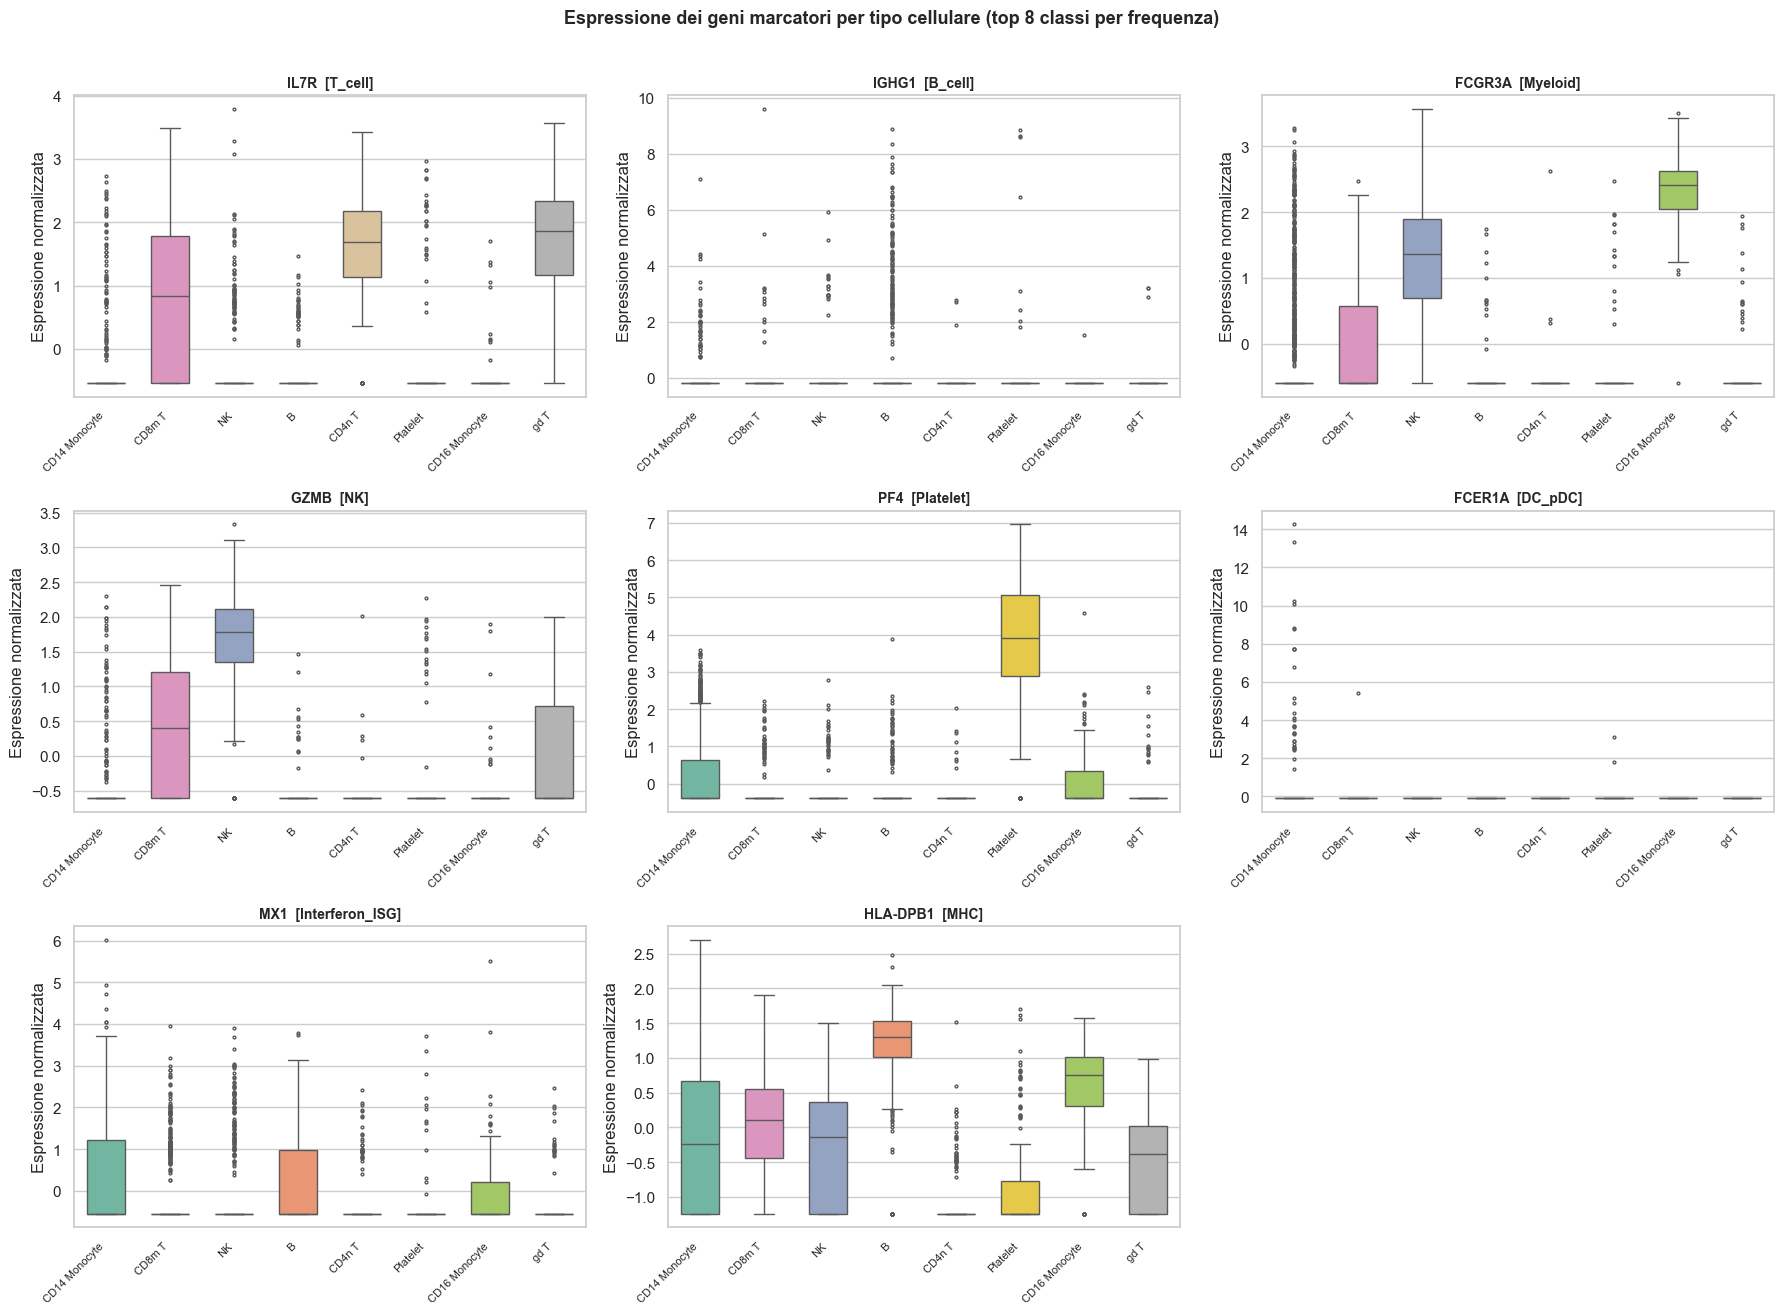

Figura salvata.


In [ ]:
# Top 8 classi per frequenza 
top_classes = y_train.value_counts().head(8).index.tolist()
mask_tc     = y_train.isin(top_classes)
genes_plot  = list(rep_genes.values())[:9]   # max 9 subplot
n_plots     = len(genes_plot)

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes_flat = axes.flatten()

for i, gene in enumerate(genes_plot):
    ax = axes_flat[i]
    data = pd.DataFrame({
        "cell_type" : y_train[mask_tc].values,
        gene        : X_train.loc[mask_tc, gene].values
    })
    sns.boxplot(
        data=data, x="cell_type", y=gene, order=top_classes,
        hue="cell_type", legend=False,
        ax=ax, width=0.6, fliersize=2,
        palette="Set2"
    )
    # Gruppo di appartenenza
    gruppo = next((g for g, v in rep_genes.items() if v == gene), "")
    ax.set_title(f"{gene}  [{gruppo}]", fontweight="bold", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("Espressione normalizzata")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Nascondi subplot vuoti
for j in range(n_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    "Espressione dei geni marcatori per tipo cellulare (top 8 classi per frequenza)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_boxplot_marker_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")


## 7. Matrice di correlazione


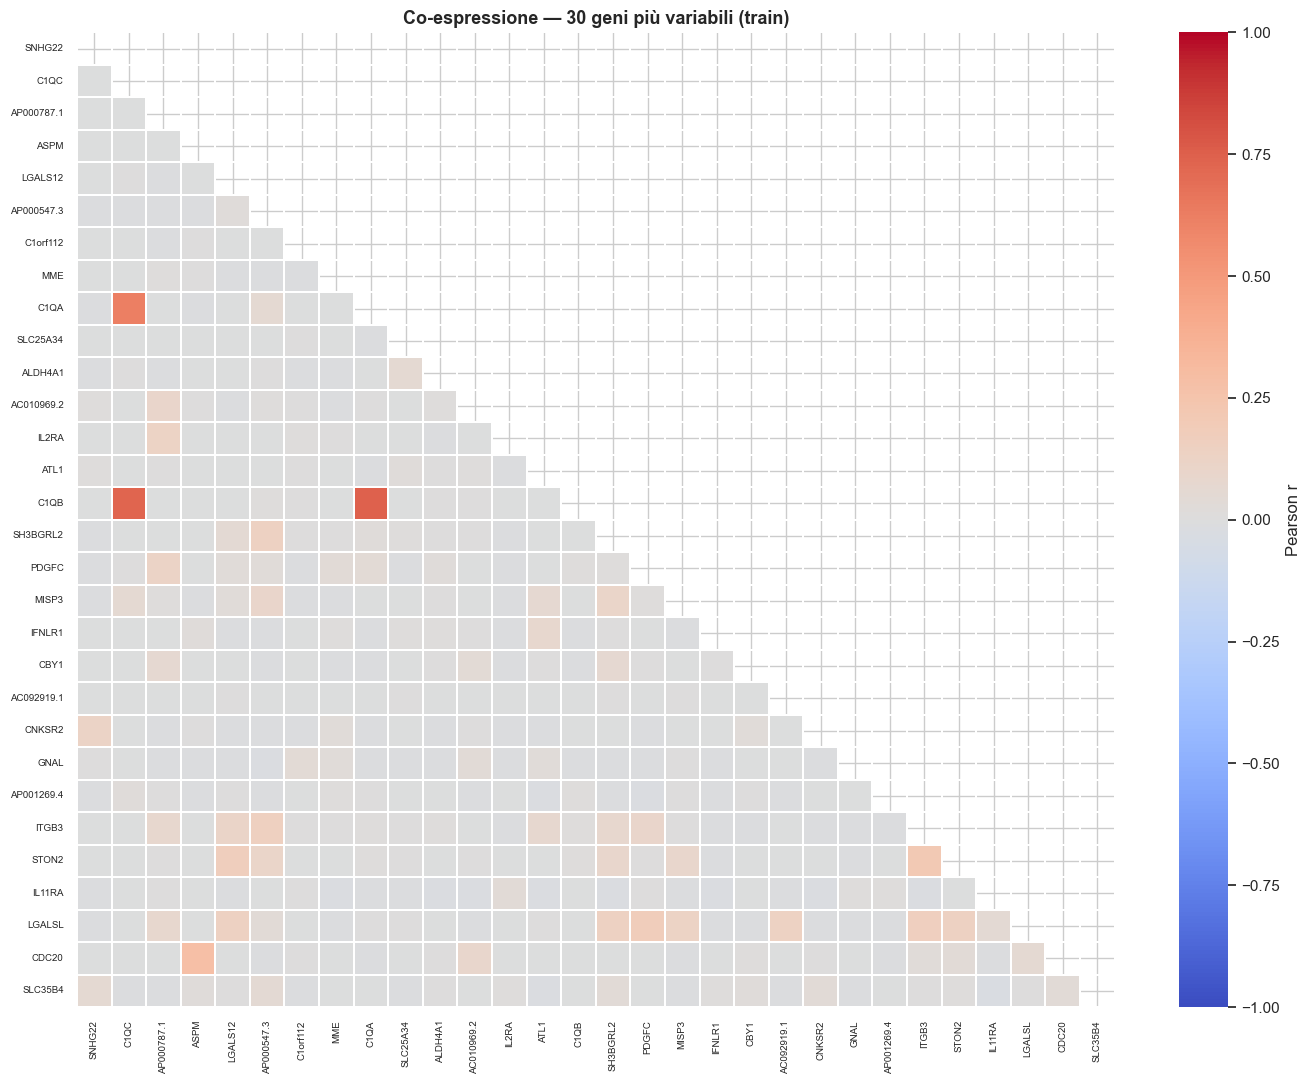

Figura salvata.

Top 8 coppie di geni più correlate (co-espressione):
C1QB    C1QA      0.748
        C1QC      0.731
C1QA    C1QC      0.624
CDC20   ASPM      0.286
STON2   ITGB3     0.218
LGALSL  PDGFC     0.175
STON2   LGALS12   0.168
LGALSL  ITGB3     0.159


In [40]:
gene_var  = X_train.var().sort_values(ascending=False)
top30_var = gene_var.head(30).index
corr      = X_train[top30_var].corr()
mask_tri  = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask_tri, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, cbar_kws={"label": "Pearson r"}
)
ax.set_title("Co-espressione — 30 geni più variabili (train)", fontsize=13, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_correlation_top30.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

# Coppie più correlate
corr_pairs = corr.where(~mask_tri).stack().sort_values(ascending=False)
print("\nTop 8 coppie di geni più correlate (co-espressione):")
print(corr_pairs.head(8).round(3).to_string())

## 8. PCA: varianza spiegata e scatter 2D

- **8a** — Curva della varianza spiegata: dimensionalità effettiva del dataset.
- **8b** — Scatter 2D (PC1 vs PC2): separazione visiva tra tipi cellulari.


Componenti totali: 1976
Componenti per l'80% della varianza: 888
Componenti per il 90% della varianza: 1208
  Primi  10 componenti → 14.0%
  Primi  50 componenti → 20.9%
  Primi 100 componenti → 27.0%
  Primi 200 componenti → 37.4%


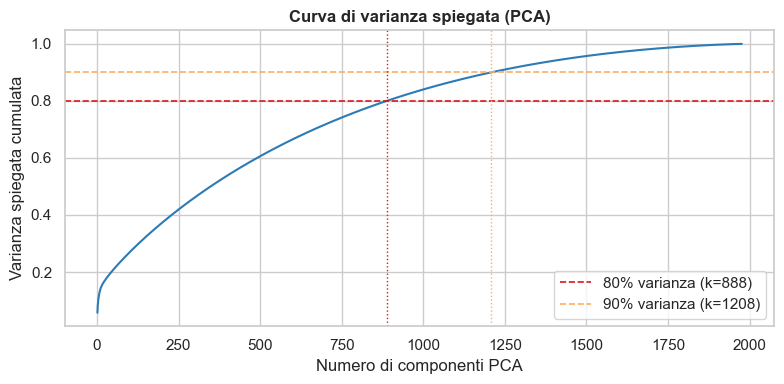

Figura salvata.


In [ ]:
# Varianza  
pca_full = PCA(random_state=42).fit(X_train.values)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = len(cum_var)

k80 = int(np.searchsorted(cum_var, 0.80)) + 1
k90 = int(np.searchsorted(cum_var, 0.90)) + 1
print(f"Componenti totali: {n_comp}")
print(f"Componenti per l'80% della varianza: {k80}")
print(f"Componenti per il 90% della varianza: {k90}")
for k in [10, 50, 100, 200]:
    print(f"  Primi {k:>3d} componenti → {cum_var[k-1]:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_comp + 1), cum_var, color="#2c7bb6", lw=1.5)
ax.axhline(0.80, ls="--", color="#d7191c", lw=1.2, label=f"80% varianza (k={k80})")
ax.axhline(0.90, ls="--", color="#fdae61", lw=1.2, label=f"90% varianza (k={k90})")
ax.axvline(k80,  ls=":",  color="#d7191c", lw=1.0)
ax.axvline(k90,  ls=":",  color="#fdae61", lw=1.0)
ax.set_xlabel("Numero di componenti PCA")
ax.set_ylabel("Varianza spiegata cumulata")
ax.set_title("Curva di varianza spiegata (PCA)", fontweight="bold")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")

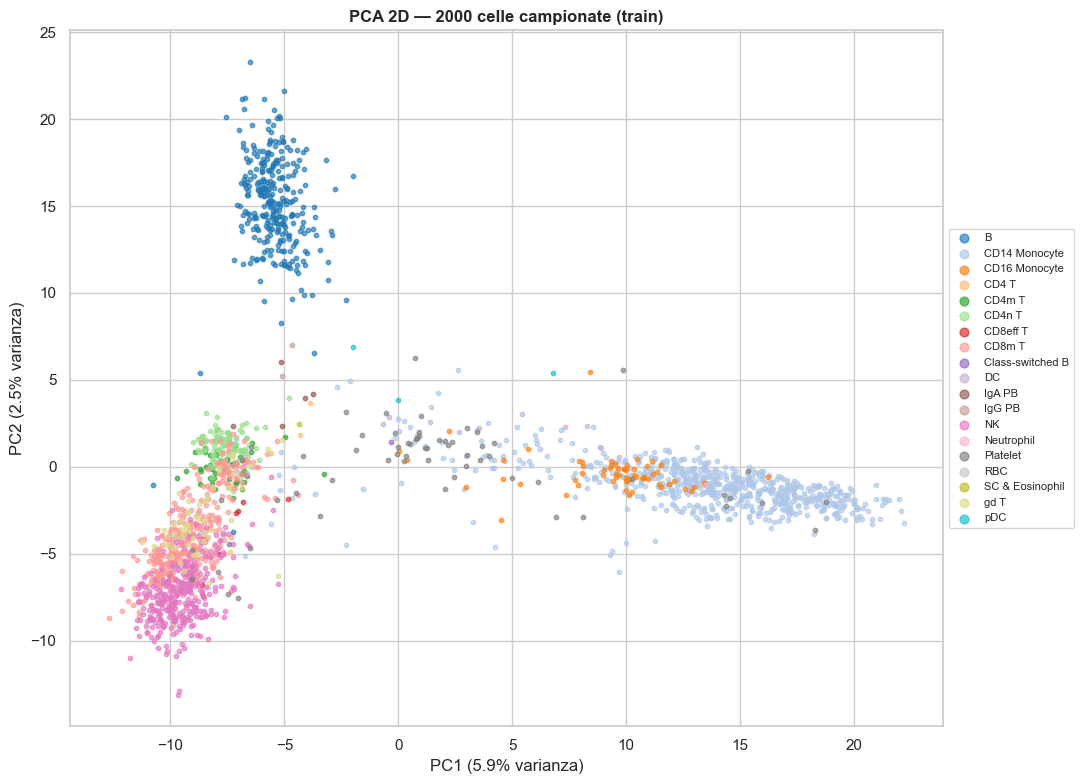

Figura salvata.


In [ ]:
# Scatter PCA 2D 
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)
pca2  = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_train.iloc[idx].values)
lab    = y_train.iloc[idx].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("tab20", n_colors=lab.nunique())
for color, ct in zip(palette, sorted(lab.unique())):
    m = (lab == ct).values
    ax.scatter(coords[m, 0], coords[m, 1], s=10, alpha=0.65, label=ct, color=color)

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} varianza)")
ax.set_title(f"PCA 2D — {len(idx)} celle campionate (train)", fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8, markerscale=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata.")